Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Generate Synthetic Dataset

In [2]:
np.random.seed(42)

In [3]:
n = 100000

In [4]:
df = pd.DataFrame({
    "Customer_ID": range(1, n+1),
    "Age": np.random.randint(18, 71, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200001, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n),
})

In [5]:
df["Churn"] = (
    (df["Balance"] < 50000) &
    (df["IsActiveMember"] == "No") &
    (df["Tenure"] < 3)
).astype(int)

In [6]:
print(df.head())

   Customer_ID  Age  Gender  Tenure  Balance  CreditScore  EstimatedSalary  \
0            1   56  Female       3   138803          718           121992   
1            2   69    Male       1   174102          534           125877   
2            3   46  Female      10    90135          653            39062   
3            4   32    Male       6   160284          787            66364   
4            5   60  Female       6    24298          681           116045   

   NumOfProducts IsActiveMember  Churn  
0              4             No      0  
1              2             No      0  
2              2            Yes      0  
3              2            Yes      0  
4              2            Yes      0  


Data Cleaning & Preprocessing

In [7]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64


In [8]:
print("\nData Types:\n", df.dtypes)


Data Types:
 Customer_ID         int64
Age                 int64
Gender             object
Tenure              int64
Balance             int64
CreditScore         int64
EstimatedSalary     int64
NumOfProducts       int64
IsActiveMember     object
Churn               int64
dtype: object


In [9]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["IsActiveMember"] = df["IsActiveMember"].map({"No": 0, "Yes": 1})

Descriptive Statistics

In [10]:
print("\nMean:\n", df.mean(numeric_only=True))


Mean:
 Customer_ID        50000.50000
Age                   43.98406
Gender                 0.49891
Tenure                 4.98876
Balance            99742.23367
CreditScore          599.94275
EstimatedSalary    79959.02136
NumOfProducts          2.50198
IsActiveMember         0.49893
Churn                  0.03422
dtype: float64


In [11]:
print("\nMedian:\n", df.median(numeric_only=True))


Median:
 Customer_ID        50000.5
Age                   44.0
Gender                 0.0
Tenure                 5.0
Balance            99729.0
CreditScore          599.0
EstimatedSalary    80008.5
NumOfProducts          3.0
IsActiveMember         0.0
Churn                  0.0
dtype: float64


In [12]:
print("\nStd Dev:\n", df.std(numeric_only=True))


Std Dev:
 Customer_ID        28867.657797
Age                   15.251827
Gender                 0.500001
Tenure                 3.163744
Balance            57670.541911
CreditScore          173.269555
EstimatedSalary    40445.277417
NumOfProducts          1.117734
IsActiveMember         0.500001
Churn                  0.181795
dtype: float64


In [13]:
print("\nMode:\n", df.mode().iloc[0])


Mode:
 Customer_ID            1.0
Age                   40.0
Gender                 0.0
Tenure                 4.0
Balance            67150.0
CreditScore          521.0
EstimatedSalary    11429.0
NumOfProducts          3.0
IsActiveMember         0.0
Churn                  0.0
Name: 0, dtype: float64


Churn Behavior Analysis

In [14]:
print("\nChurn Count:\n", df["Churn"].value_counts())


Churn Count:
 Churn
0    96578
1     3422
Name: count, dtype: int64


In [15]:
print("\nChurn Percentage:\n", df["Churn"].value_counts(normalize=True) * 100)


Churn Percentage:
 Churn
0    96.578
1     3.422
Name: proportion, dtype: float64


Group-Based Analysis

In [16]:
print("\nAge vs Churn:\n", df.groupby("Age")["Churn"].mean())


Age vs Churn:
 Age
18    0.033040
19    0.039625
20    0.028571
21    0.030143
22    0.046001
23    0.032769
24    0.035676
25    0.040729
26    0.033244
27    0.030987
28    0.033732
29    0.032662
30    0.035863
31    0.033677
32    0.039042
33    0.035827
34    0.029949
35    0.042342
36    0.031529
37    0.033387
38    0.034961
39    0.039563
40    0.026236
41    0.035356
42    0.031333
43    0.033368
44    0.032450
45    0.036999
46    0.029243
47    0.028365
48    0.028682
49    0.034483
50    0.039739
51    0.039216
52    0.029851
53    0.037678
54    0.035637
55    0.035421
56    0.038563
57    0.034170
58    0.037666
59    0.033210
60    0.031544
61    0.029805
62    0.040837
63    0.025556
64    0.040892
65    0.030444
66    0.031505
67    0.037694
68    0.034133
69    0.031136
70    0.028415
Name: Churn, dtype: float64


In [17]:
print("\nGender vs Churn:\n", df.groupby("Gender")["Churn"].mean())


Gender vs Churn:
 Gender
0    0.033367
1    0.035076
Name: Churn, dtype: float64


In [18]:
print("\nActive vs Churn:\n", df.groupby("IsActiveMember")["Churn"].mean())


Active vs Churn:
 IsActiveMember
0    0.068294
1    0.000000
Name: Churn, dtype: float64


In [19]:
print("\nProducts vs Churn:\n", df.groupby("NumOfProducts")["Churn"].mean())


Products vs Churn:
 NumOfProducts
1    0.033805
2    0.034179
3    0.033856
4    0.035039
Name: Churn, dtype: float64


Relationship Analysis

In [20]:
print("\nBalance vs Churn:\n", df.groupby("Churn")["Balance"].mean())


Balance vs Churn:
 Churn
0    102383.608016
1     25195.579193
Name: Balance, dtype: float64


In [21]:
print("\nCredit Score vs Churn:\n", df.groupby("Churn")["CreditScore"].mean())


Credit Score vs Churn:
 Churn
0    600.023401
1    597.666569
Name: CreditScore, dtype: float64


In [22]:
print("\nTenure vs Churn:\n", df.groupby("Churn")["Tenure"].mean())


Tenure vs Churn:
 Churn
0    5.130817
1    0.979544
Name: Tenure, dtype: float64


Data Visualization

Bar Chart (Churn Count)

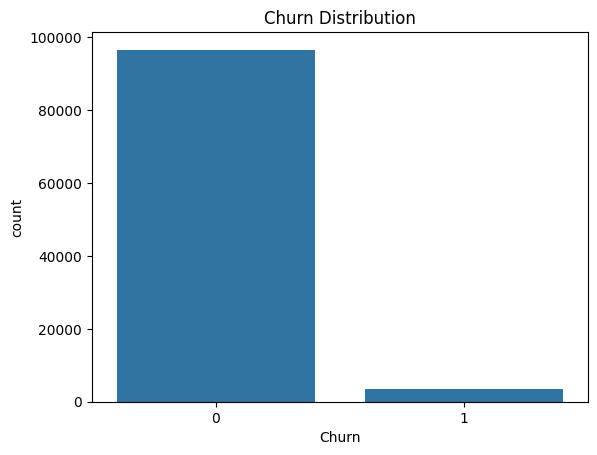

In [23]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

Pie Chart

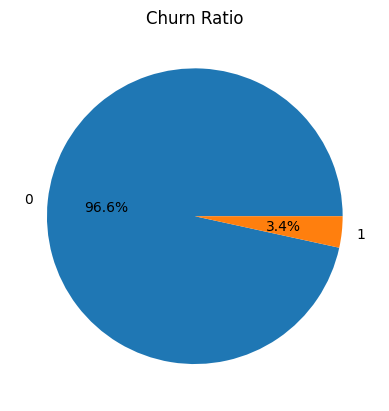

In [24]:
df["Churn"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Churn Ratio")
plt.ylabel("")
plt.show()

Histogram

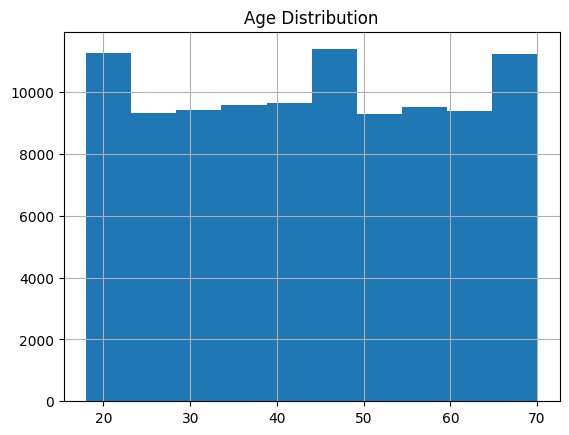

In [25]:
df["Age"].hist()
plt.title("Age Distribution")
plt.show()

Scatter Plot

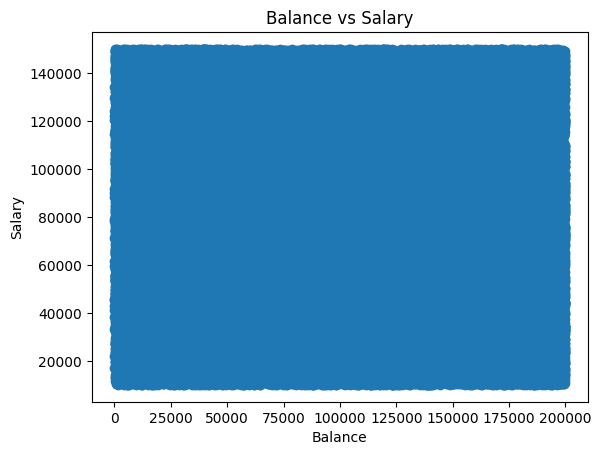

In [26]:
plt.scatter(df["Balance"], df["EstimatedSalary"])
plt.title("Balance vs Salary")
plt.xlabel("Balance")
plt.ylabel("Salary")
plt.show()

Box Plot

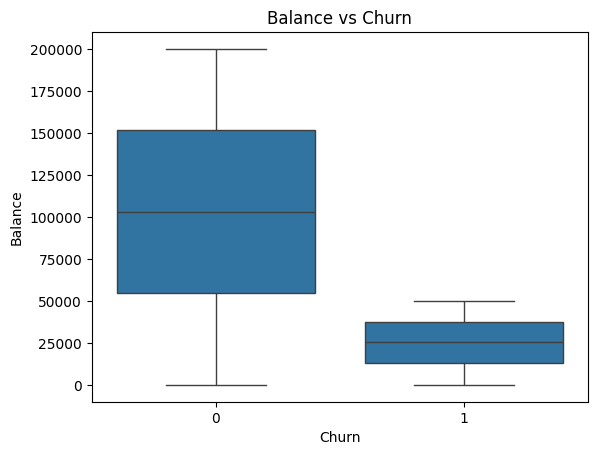

In [27]:
sns.boxplot(x="Churn", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.show()

Heatmap

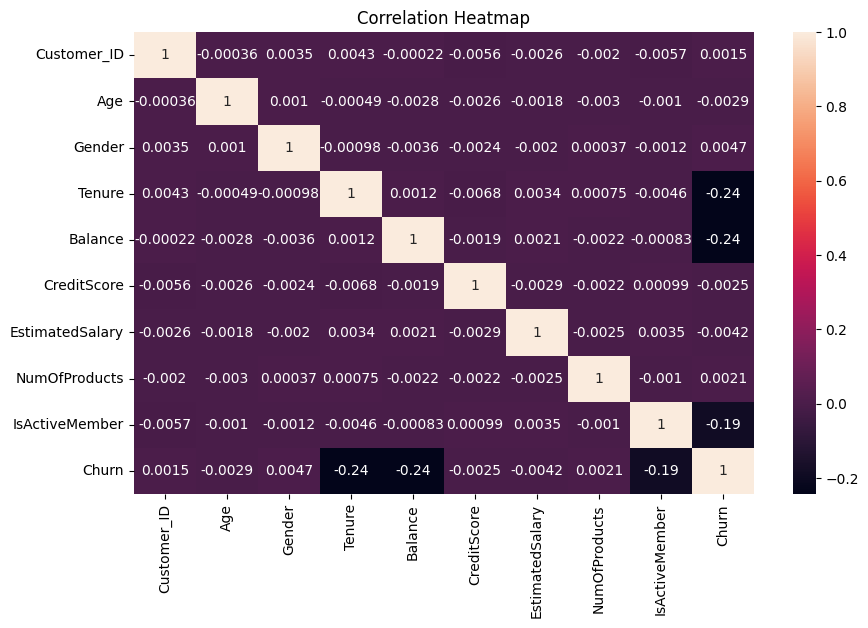

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()